In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [30]:
# UMUC1 HT8
umuc1_ht8_qpcr_df = pd.read_csv('/Users/timothy/Documents/GitHub/EV-Resistance-analysis/qPCR-validation/qpcr_data/QPCR_6-12_UMUC1-HT8.csv')
umuc1_ht8_rnaseq_df = pd.read_csv('/Users/timothy/Documents/GitHub/EV-Resistance-analysis/qPCR-validation/bulkRNAseq_data/bulkRNA_UMUC1_parental_vs_resistant.csv')

# RT112 2F2E/2F2L
rt112_2f2e_2f2l_qpcr_df = pd.read_csv('/Users/timothy/Documents/GitHub/EV-Resistance-analysis/qPCR-validation/qpcr_data/QPCR_6-15_RT112-ZF2E-ZF2L.csv')
rt112_2f2e_2f2l_rnaseq_df = pd.read_csv('/Users/timothy/Documents/GitHub/EV-Resistance-analysis/qPCR-validation/bulkRNAseq_data/bulkRNA_RT112_parental_vs_resistant.csv')

# 647V-1C2
v647_1c2_qpcr_df = pd.read_csv('/Users/timothy/Documents/GitHub/EV-Resistance-analysis/qPCR-validation/qpcr_data/QPCR_6-16_647V-1C2.csv')
v647_1c2_rnaseq_df = pd.read_csv('/Users/timothy/Documents/GitHub/EV-Resistance-analysis/qPCR-validation/bulkRNAseq_data/bulkRNA_647V_parental_vs_resistant.csv')

tim_upregulated = [
    "GJA1",
    "AGAP2",
    "DNM3",
    "ADAM12",
    "ABCB1",
    "IL6",
    "FZD8",
    "TUBA4A",
    "F2R",
    "CTSE",
    "CTSF",
    "RET"
]

tim_downregulated = [
    "FAP",
    "EHD3",
    "PSALP1",
    "PDZK1",
    "ABCG1",
    "BBC3",
    "CHMP4B",
    "CAV1",
    "PPT2",
    "NEDD4L",
]

will_upregulated = [
    "ZNF611",
    "MELTF",
    "IL32",
    "UST",
    "TMCC2",
    "PLOD2",
    "SAT1"
]


will_downregulated = ["GJB1",
    "KRT81",
    "DAPK1",
    "ZBED2",
    "ACAT2",
    "WNT10A",
    "UPK1B",
    "IGFBP3",
    "S100A14",
    "SLC7A5",
    "EMP1",
    "BCAT1",
    "TPX2",
    "CLIC4",
    "SH2D4A",
]

In [19]:
rt112_2f2e_2f2l_rnaseq_df

,baseMean,log2FoldChange,lfcSE,pvalue,padj,GeneSymbol,gene_type
0,1933.153304,-3.371088,0.083777,0.000000,0.000000,F3,protein_coding
1,7291.676853,5.950702,0.084651,0.000000,0.000000,TXNIP,protein_coding
2,1894.517793,-4.159758,0.099946,0.000000,0.000000,DHRS9,protein_coding
3,1409.878109,-4.871269,0.118664,0.000000,0.000000,AREG,protein_coding
4,1662.933358,-3.881998,0.092718,0.000000,0.000000,SLC7A11,protein_coding
...,...,...,...,...,...,...,...
24516,673.297854,0.000190,0.100564,0.999590,0.999753,NEURL4,protein_coding
24517,2.990742,0.000552,0.604188,0.999775,0.999898,RP4-612C19.2,processed_pseudogene
24518,4.795836,0.000778,0.579535,0.999902,0.999902,RP11-392O17.2,lincRNA
24519,22.054377,0.000676,0.385402,0.999900,0.999902,LINC00216,lincRNA


In [4]:
def calculate_ddct(df, goi, hkg, reference_sample, test_sample):
    """
    Calculate 2^-ΔΔCt for qPCR data.

    Parameters:
        df               : DataFrame with columns [Sample Name, Target Name, CT]
        goi              : Gene of interest, string, case-insensitive
        hkg              : Housekeeping gene string OR list of housekeeping genes
        reference_sample : Reference/control sample name
        test_sample      : Test sample name

    Returns:
        final 2^-ΔΔCt
    """

    df = df.copy()

    # Normalize columns
    df['Target Name'] = df['Target Name'].astype(str).str.lower().str.strip()
    df['Sample Name'] = df['Sample Name'].astype(str).str.strip()

    goi = goi.lower().strip()
    reference_sample = reference_sample.strip()
    test_sample = test_sample.strip()

    # Allow hkg to be a string or a list
    if isinstance(hkg, str):
        hkg_list = [hkg.lower().strip()]
    else:
        hkg_list = [gene.lower().strip() for gene in hkg]

    # Replace 'Undetermined' or bad CT values with NaN
    df['CT'] = pd.to_numeric(df['CT'], errors='coerce')

    def mean_ct(sample, target):
        vals = df[
            (df['Sample Name'] == sample) &
            (df['Target Name'] == target)
        ]['CT']

        if vals.empty:
            raise ValueError(f"No CT values found for {sample} / {target}")

        if vals.isna().all():
            raise ValueError(f"All CT values are Undetermined for {sample} / {target}")

        return vals.mean()

    def mean_hkg_ct(sample):
        """
        Average the mean CT of each housekeeping gene.
        This prevents a housekeeping gene with more replicates from being weighted more heavily.
        """
        hkg_means = [mean_ct(sample, gene) for gene in hkg_list]
        return np.mean(hkg_means)

    # Average CT values
    ct_goi_ref = mean_ct(reference_sample, goi)
    ct_goi_test = mean_ct(test_sample, goi)

    ct_hkg_ref = mean_hkg_ct(reference_sample)
    ct_hkg_test = mean_hkg_ct(test_sample)

    # ΔCt = CT(GOI) - CT(HKG average)
    dct_reference = ct_goi_ref - ct_hkg_ref
    dct_test = ct_goi_test - ct_hkg_test

    # ΔΔCt = ΔCt(test) - ΔCt(reference)
    ddct = dct_test - dct_reference

    # 2^-ΔΔCt
    expression = 2 ** (-ddct)

    return expression

In [8]:
# results = calculate_ddct(
#     df=qpcr_df,
#     goi="CLIC4",
#     hkg=["hprt", "gapdh"],
#     reference_sample="1C2",
#     test_sample="647V"
# )
# print(results)

# for target in pd.unique(qpcr_df['Target Name']):
#     print(target)

In [76]:
def plot_qpcr_vs_rnaseq_mice(
    qpcr_df,
    rnaseq_df,
    hkg,
    reference_sample,
    test_sample,
    color1='steelblue',
    color2='salmon',
    genes_to_include=None
):
    """
    Plots grouped bars comparing qPCR log2FC vs RNAseq log2FC for each target gene.
    Parameters:
        qpcr_df          : qPCR DataFrame [Sample Name, Target Name, CT]
        rnaseq_df        : RNAseq DataFrame with Gene column + comparison columns as headers
        hkg              : Housekeeping gene or list of housekeeping genes (case-insensitive)
        reference_sample : Reference sample name
        test_sample      : Test sample name
        color1           : Bar color for qPCR
        color2           : Bar color for RNAseq
        genes_to_include : Optional list of genes to plot, in given order
    """
    comparison = f"{test_sample} vs {reference_sample}"
    if comparison not in rnaseq_df.columns:
        raise ValueError(
            f"Column '{comparison}' not found in RNAseq data. "
            f"Available: {list(rnaseq_df.columns)}"
        )

    # --- Clean qPCR ---
    qpcr_df = qpcr_df.copy()
    qpcr_df['Target Name'] = qpcr_df['Target Name'].str.lower().str.strip()
    qpcr_df['Sample Name'] = qpcr_df['Sample Name'].str.strip()
    qpcr_df['CT'] = pd.to_numeric(qpcr_df['CT'], errors='coerce')

    # --- Normalize hkg to list ---
    if isinstance(hkg, str):
        hkg_list = [hkg.lower().strip()]
    else:
        hkg_list = [g.lower().strip() for g in hkg]
    if not hkg_list:
        raise ValueError("At least one housekeeping gene must be provided.")
    hkg_set = set(hkg_list)

    qpcr_targets = set(qpcr_df['Target Name'].unique())

    # --- Select GOIs ---
    if genes_to_include is None:
        goi_list = [t for t in qpcr_df['Target Name'].unique() if t not in hkg_set]
    else:
        seen = set()
        goi_list = []
        for g in genes_to_include:
            g_lower = g.lower().strip()
            if g_lower in seen:
                continue
            seen.add(g_lower)
            if g_lower in hkg_set:
                print(f"Skipping '{g.upper()}': housekeeping gene.")
            elif g_lower not in qpcr_targets:
                print(f"Warning: '{g.upper()}' not found in qPCR data — skipped.")
            else:
                goi_list.append(g_lower)

    # --- Calculate qPCR log2FC ---
    qpcr_log2fc = {}
    for goi in goi_list:
        try:
            res = calculate_ddct(qpcr_df, goi, hkg_list, reference_sample, test_sample)
            qpcr_log2fc[goi] = np.log2(res)
        except ValueError as e:
            print(f"Skipping {goi.upper()}: {e}")

    genes = [g for g in goi_list if g in qpcr_log2fc]
    if not genes:
        raise ValueError("No genes available to plot after filtering.")

    # --- RNAseq lookup ---
    rnaseq_df = rnaseq_df.copy()
    rnaseq_df['Gene'] = rnaseq_df['Gene'].str.lower().str.strip()
    rnaseq_lookup = pd.to_numeric(rnaseq_df.set_index('Gene')[comparison], errors='coerce')

    qpcr_vals = [qpcr_log2fc[g] for g in genes]
    rnaseq_vals = [rnaseq_lookup.get(g, np.nan) for g in genes]

    for g, rv in zip(genes, rnaseq_vals):
        if np.isnan(rv):
            print(f"Warning: '{g.upper()}' not found in RNAseq data — bar will be absent.")

    # --- Plot ---
    x = np.arange(len(genes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(6, len(genes) * 1.4), 5))

    bars1 = ax.bar(x - width / 2, qpcr_vals, width, label='qPCR', color=color1, edgecolor='black', linewidth=0.8)
    bars2 = ax.bar(x + width / 2, rnaseq_vals, width, label='Bulk RNAseq', color=color2, edgecolor='black', linewidth=0.8)

    for bar in bars1 + bars2:
        h = bar.get_height()
        if not np.isnan(h):
            y = h + (0.05 if h >= 0 else -0.15)
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                f'{h:.2f}',
                ha='center',
                va='bottom',
                fontsize=8,
                fontweight='bold'
            )

    hkg_label = ", ".join(g.upper() for g in hkg_list)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_ylabel('log$_2$ Fold Change', fontsize=12)
    ax.set_title(f'{test_sample} vs {reference_sample}\n(qPCR normalized to {hkg_label})', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([g.upper() for g in genes], rotation=45, ha='right')
    ax.legend(fontsize=10)

    plt.tight_layout()
    fname = f'qpcr_vs_rnaseq_{test_sample}_vs_{reference_sample}.png'
    plt.savefig(fname, dpi=300)
    plt.show()
    print(f"Saved as {fname}")

In [113]:
qpcr_mice_df = pd.read_csv('/Users/timothy/Documents/GitHub/EV-Resistance-analysis/data/mice/qpcr_B-B1-U-U1.csv')
rnaseq_mice_df = pd.read_csv('/Users/timothy/Documents/GitHub/EV-Resistance-analysis/data/mice/bulkrnaseq_B-B1-U-U1.csv')

In [114]:
qpcr_mice_df

,Sample Name,Target Name,CT
0,B1,mNectin4,30.553
1,B1,mNectin4,30.569
2,U1,mNectin4,Undetermined
3,U1,mNectin4,Undetermined
4,B,mNectin4,32.044
...,...,...,...
107,U1,mACTIN,20.856
108,B,mACTIN,19.480
109,B,mACTIN,19.585
110,U,mACTIN,19.806


In [115]:
pparg_genes = ['mNECTIN4', 'mPPARG', 'mFABP4']
luminal_genes = ['mgata3', 'mfoxa1','mgrhl2']
basal_genes = ['mkrt6a','mkrt14','mkrt20']
epithelial_genes = ['mecad','mepcam']
macrophage_genes=['mcsf1']

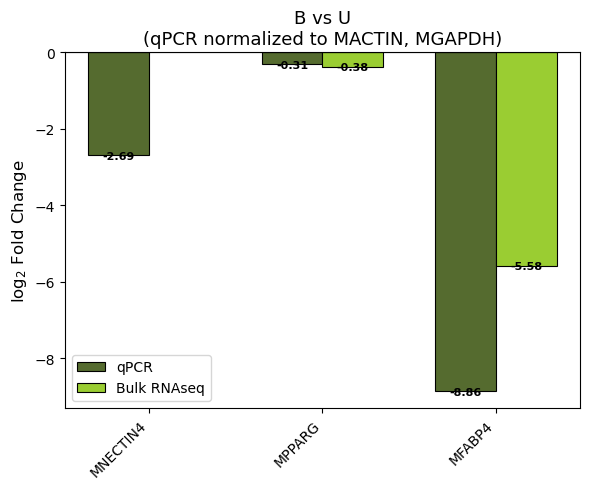

Saved as qpcr_vs_rnaseq_B_vs_U.png


In [136]:
plot_qpcr_vs_rnaseq_mice(qpcr_mice_df, rnaseq_mice_df, hkg=['mactin','mgapdh'], 
                         reference_sample='U', 
                         test_sample='B', color1='darkolivegreen', color2='yellowgreen',
                         genes_to_include=pparg_genes)

In [10]:
def plot_qpcr_vs_rnaseq(
    qpcr_df,
    rnaseq_df,
    hkg,
    reference_sample,
    test_sample,
    ncols=6,
    color1='darkturquoise',
    color2='mediumvioletred',
    genes_to_include=None
):
    """
    Plots multi-row grouped bar chart comparing qPCR log2FC vs RNAseq log2FC.
    All rows share the same y-axis scale.

    Parameters:
        qpcr_df          : qPCR DataFrame with columns [Sample Name, Target Name, CT]
        rnaseq_df        : DESeq2-style DataFrame with columns [log2FoldChange, GeneSymbol, ...]
        hkg              : Housekeeping gene name OR list of housekeeping gene names
        reference_sample : Reference sample name
        test_sample      : Test sample name
        ncols            : Number of genes per row
        genes_to_include : Optional list of genes to plot, in the given order
    """

    def _label_bars(ax, bars):
        for bar in bars:
            h = bar.get_height()
            if np.isnan(h):
                continue

            y = h + (0.05 if h >= 0 else -0.05)
            va = 'bottom' if h >= 0 else 'top'

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                f'{h:.2f}',
                ha='center',
                va=va,
                fontsize=7,
                fontweight='bold'
            )

    # --- qPCR: clean input ---
    qpcr_df = qpcr_df.copy()
    qpcr_df['Target Name'] = qpcr_df['Target Name'].astype(str).str.lower().str.strip()
    qpcr_df['Sample Name'] = qpcr_df['Sample Name'].astype(str).str.strip()
    qpcr_df['CT'] = pd.to_numeric(qpcr_df['CT'], errors='coerce')

    # Allow hkg to be a string or a list
    if isinstance(hkg, str):
        hkg_list = [hkg.lower().strip()]
    else:
        hkg_list = [gene.lower().strip() for gene in hkg]

    if len(hkg_list) == 0:
        raise ValueError("At least one housekeeping gene must be provided.")

    hkg_set = set(hkg_list)
    qpcr_targets = set(qpcr_df['Target Name'].unique())

    # --- Select GOIs ---
    if genes_to_include is None:
        goi_list = [
            t for t in qpcr_df['Target Name'].unique()
            if t not in hkg_set
        ]
    else:
        # Normalize requested genes, remove duplicates, and preserve input order
        seen = set()
        requested_genes = []

        for g in genes_to_include:
            g_lower = g.lower().strip()
            if g_lower not in seen:
                requested_genes.append(g_lower)
                seen.add(g_lower)

        goi_list = []

        for g in requested_genes:
            if g in hkg_set:
                print(f"Skipping '{g.upper()}': this is one of the housekeeping genes.")
            elif g not in qpcr_targets:
                print(f"Warning: '{g.upper()}' not found in qPCR data — skipped.")
            else:
                goi_list.append(g)

    # --- Calculate qPCR log2FC ---
    qpcr_log2fc = {}

    for goi in goi_list:
        try:
            res = calculate_ddct(
                qpcr_df,
                goi,
                hkg_list,
                reference_sample,
                test_sample
            )

            qpcr_log2fc[goi] = np.log2(res)

        except ValueError as e:
            print(f"Skipping {goi.upper()}: {e}")

    genes = [g for g in goi_list if g in qpcr_log2fc]

    if len(genes) == 0:
        raise ValueError("No genes available to plot after filtering.")

    # --- RNAseq: extract log2FC from DESeq2 results table ---
    rnaseq_df = rnaseq_df.copy()
    rnaseq_df['GeneSymbol'] = rnaseq_df['GeneSymbol'].astype(str).str.lower().str.strip()

    rnaseq_lookup = pd.to_numeric(
        rnaseq_df.set_index('GeneSymbol')['log2FoldChange'],
        errors='coerce'
    )

    qpcr_vals = [qpcr_log2fc[g] for g in genes]
    rnaseq_vals = [rnaseq_lookup.get(g, np.nan) for g in genes]

    for g, rv in zip(genes, rnaseq_vals):
        if np.isnan(rv):
            print(f"Warning: '{g.upper()}' not found in RNAseq data — bar will be absent.")

    # --- Plot as multi-row grouped bar chart ---
    width = 0.35
    nrows = math.ceil(len(genes) / ncols)

    fig, axes = plt.subplots(
        nrows,
        1,
        figsize=(ncols * 1.4, nrows * 4),
        sharey=True
    )

    if nrows == 1:
        axes = [axes]

    for row in range(nrows):
        ax = axes[row]

        row_genes = genes[row * ncols:(row + 1) * ncols]
        row_qpcr = qpcr_vals[row * ncols:(row + 1) * ncols]
        row_rnaseq = rnaseq_vals[row * ncols:(row + 1) * ncols]

        x = np.arange(len(row_genes))

        bars1 = ax.bar(
            x - width / 2,
            row_qpcr,
            width,
            color=color1,
            edgecolor='black',
            linewidth=0.8
        )

        bars2 = ax.bar(
            x + width / 2,
            row_rnaseq,
            width,
            color=color2,
            edgecolor='black',
            linewidth=0.8
        )

        _label_bars(ax, bars1)
        _label_bars(ax, bars2)

        ax.axhline(y=0, color='black', linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([g.upper() for g in row_genes], rotation=45, ha='right')
        ax.set_ylabel('log$_2$FC', fontsize=10)

    axes[0].legend(
        handles=[
            plt.Rectangle((0, 0), 1, 1, color=color1, ec='black'),
            plt.Rectangle((0, 0), 1, 1, color=color2, ec='black')
        ],
        labels=['qPCR', 'Bulk RNAseq'],
        fontsize=10
    )

    hkg_label = ", ".join([gene.upper() for gene in hkg_list])

    fig.suptitle(
        f'{test_sample} vs {reference_sample} normalized to {hkg_label}',
        fontsize=12,
        fontweight='bold'
    )

    plt.tight_layout()

    fname = f'qpcr_vs_rnaseq_{test_sample}_vs_{reference_sample}.png'
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Saved as {fname}")

In [13]:
endocytosis_confirmed = [
    "AGAP2", "DNM3", "RET", "F2R", "MELTF"
]

EMT_confirmed = [
    "ADAM12", "FZD8", "PLOD2"
]

immune_modulation_confirmed = [
    "IL6", "ZBED2"
]

apoptosis_confirmed = [
    "SAT1", "UPK1B"
]

uncategorized_confirmed = [
    "ZNF611", "UST", "TMCC2"
]

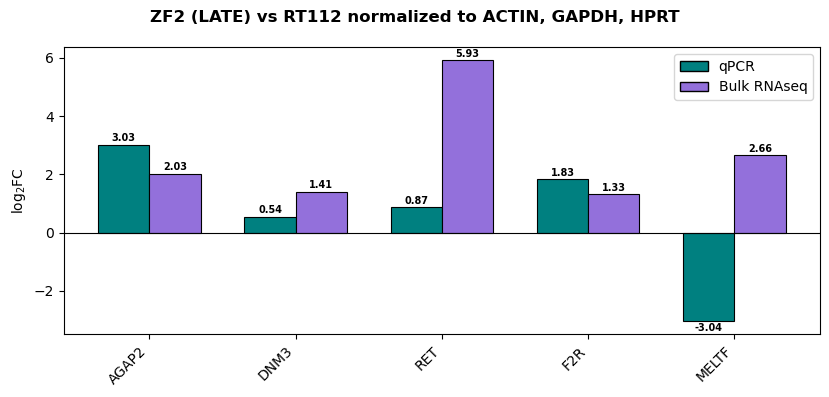

Saved as qpcr_vs_rnaseq_ZF2 (LATE)_vs_RT112.png


In [14]:
plot_qpcr_vs_rnaseq(
    qpcr_df=qpcr_df,
    rnaseq_df=rnaseq_df,
    hkg=["actin", "gapdh", "hprt"],
    test_sample="ZF2 (LATE)",
    reference_sample="RT112",
    genes_to_include=endocytosis_confirmed,
    color1='teal', color2='mediumpurple'
)

In [56]:
def plot_qpcr_only(
    qpcr_df,
    hkg,
    reference_sample,
    test_sample,
    ncols=6,
    color='darkturquoise',
    genes_to_include=None
):
    """
    Plots multi-row bar chart of qPCR log2FC values.
    Parameters:
        qpcr_df          : qPCR DataFrame with columns [Sample Name, Target Name, CT]
        hkg              : Housekeeping gene name OR list of housekeeping gene names
        reference_sample : Reference sample name
        test_sample      : Test sample name
        ncols            : Number of genes per row
        color            : Bar color
        genes_to_include : Optional list of genes to plot, in the given order
    """
    def _label_bars(ax, bars):
        for bar in bars:
            h = bar.get_height()
            if np.isnan(h):
                continue
            y  = h + (0.05 if h >= 0 else -0.05)
            va = 'bottom' if h >= 0 else 'top'
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                f'{h:.2f}',
                ha='center',
                va=va,
                fontsize=7,
                fontweight='bold'
            )

    qpcr_df = qpcr_df.copy()
    qpcr_df['Target Name'] = qpcr_df['Target Name'].astype(str).str.lower().str.strip()
    qpcr_df['Sample Name'] = qpcr_df['Sample Name'].astype(str).str.strip()
    qpcr_df['CT'] = pd.to_numeric(qpcr_df['CT'], errors='coerce')

    if isinstance(hkg, str):
        hkg_list = [hkg.lower().strip()]
    else:
        hkg_list = [gene.lower().strip() for gene in hkg]

    if len(hkg_list) == 0:
        raise ValueError("At least one housekeeping gene must be provided.")

    hkg_set     = set(hkg_list)
    qpcr_targets = set(qpcr_df['Target Name'].unique())

    # Select GOIs
    if genes_to_include is None:
        goi_list = [t for t in qpcr_df['Target Name'].unique() if t not in hkg_set]
    else:
        seen, goi_list = set(), []
        for g in genes_to_include:
            g_lower = g.lower().strip()
            if g_lower in seen:
                continue
            seen.add(g_lower)
            if g_lower in hkg_set:
                print(f"Skipping '{g.upper()}': housekeeping gene.")
            elif g_lower not in qpcr_targets:
                print(f"Warning: '{g.upper()}' not found in qPCR data — skipped.")
            else:
                goi_list.append(g_lower)

    # Calculate log2FC
    qpcr_log2fc = {}
    for goi in goi_list:
        try:
            fc = calculate_ddct(qpcr_df, goi, hkg_list, reference_sample, test_sample)
            qpcr_log2fc[goi] = np.log2(fc)
        except ValueError as e:
            print(f"Skipping {goi.upper()}: {e}")

    genes = [g for g in goi_list if g in qpcr_log2fc]
    if not genes:
        raise ValueError("No genes available to plot after filtering.")

    qpcr_vals = [qpcr_log2fc[g] for g in genes]

    # Plot
    nrows = math.ceil(len(genes) / ncols)
    fig, axes = plt.subplots(nrows, 1, figsize=(ncols * 1.4, nrows * 4), sharey=True)
    if nrows == 1:
        axes = [axes]

    for row in range(nrows):
        ax         = axes[row]
        row_genes  = genes[row * ncols:(row + 1) * ncols]
        row_vals   = qpcr_vals[row * ncols:(row + 1) * ncols]
        x          = np.arange(len(row_genes))

        bars = ax.bar(x, row_vals, color=color, edgecolor='black', linewidth=0.8)
        _label_bars(ax, bars)

        ax.axhline(y=0, color='black', linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([g.upper() for g in row_genes], rotation=45, ha='right')
        ax.set_ylabel('log$_2$FC', fontsize=10)

    hkg_label = ", ".join(g.upper() for g in hkg_list)
    fig.suptitle(
        f'{test_sample} vs {reference_sample} normalized to {hkg_label}',
        fontsize=12,
        fontweight='bold'
    )
    plt.tight_layout()

    fname = f'qpcr_{test_sample}_vs_{reference_sample}.png'
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved as {fname}")

In [42]:
def individual_plot_qpcr_vs_rnaseq(
    qpcr_df,
    rnaseq_dfs,
    comparisons,
    hkg=["actin", "gapdh", "hprt"],
    color1='navy',
    color2='goldenrod',
    genes_to_include=None
):
    """
    Plots one figure per gene, each showing paired qPCR vs RNAseq log2FC bars
    for each (test, reference) comparison. All plots share the same y-axis scale.

    Parameters:
        qpcr_df         : qPCR DataFrame with columns [Sample Name, Target Name, CT]
        rnaseq_dfs      : List of DESeq2-style DataFrames (one per comparison), each with [log2FoldChange, GeneSymbol]
        comparisons     : List of (test_sample, reference_sample) tuples, matching order of rnaseq_dfs
        hkg             : Housekeeping gene name or list of housekeeping gene names
        color1          : Bar color for qPCR
        color2          : Bar color for RNAseq
        genes_to_include: Optional list of genes to plot, in given order
    """

    def _label_bars(ax, bars):
        for bar in bars:
            h = bar.get_height()
            if np.isnan(h):
                continue
            y = h + (0.05 if h >= 0 else -0.05)
            va = 'bottom' if h >= 0 else 'top'
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                f'{h:.2f}',
                ha='center',
                va=va,
                fontsize=7,
                fontweight='bold'
            )

    # --- Validate inputs ---
    if len(rnaseq_dfs) != len(comparisons):
        raise ValueError("rnaseq_dfs and comparisons must have the same length.")

    # --- Clean qPCR ---
    qpcr_df = qpcr_df.copy()
    qpcr_df['Target Name'] = qpcr_df['Target Name'].astype(str).str.lower().str.strip()
    qpcr_df['Sample Name'] = qpcr_df['Sample Name'].astype(str).str.strip()
    qpcr_df['CT'] = pd.to_numeric(qpcr_df['CT'], errors='coerce')

    if isinstance(hkg, str):
        hkg_list = [hkg.lower().strip()]
    else:
        hkg_list = [g.lower().strip() for g in hkg]
    if not hkg_list:
        raise ValueError("At least one housekeeping gene must be provided.")
    hkg_set = set(hkg_list)
    qpcr_targets = set(qpcr_df['Target Name'].unique())

    # --- Select GOIs ---
    if genes_to_include is None:
        goi_list = [t for t in qpcr_df['Target Name'].unique() if t not in hkg_set]
    else:
        seen = set()
        goi_list = []
        for g in genes_to_include:
            g_lower = g.lower().strip()
            if g_lower in seen:
                continue
            seen.add(g_lower)
            if g_lower in hkg_set:
                print(f"Skipping '{g.upper()}': housekeeping gene.")
            elif g_lower not in qpcr_targets:
                print(f"Warning: '{g.upper()}' not found in qPCR data — skipped.")
            else:
                goi_list.append(g_lower)

    # --- Clean RNAseq DataFrames ---
    rnaseq_lookups = []
    for df in rnaseq_dfs:
        df = df.copy()
        df['GeneSymbol'] = df['GeneSymbol'].astype(str).str.lower().str.strip()
        lookup = pd.to_numeric(
            df.set_index('GeneSymbol')['log2FoldChange'],
            errors='coerce'
        )
        rnaseq_lookups.append(lookup)

    # --- Compute qPCR log2FC per gene per comparison ---
    gene_data = {}
    for goi in goi_list:
        qpcr_vals = []
        rnaseq_vals = []
        valid = False
        for (test_sample, reference_sample), rnaseq_lookup in zip(comparisons, rnaseq_lookups):
            try:
                res = calculate_ddct(qpcr_df, goi, hkg_list, reference_sample, test_sample)
                qv = np.log2(res)
                valid = True
            except ValueError as e:
                print(f"Skipping {goi.upper()} in {test_sample} vs {reference_sample}: {e}")
                qv = np.nan
            rv = rnaseq_lookup.get(goi, np.nan)
            if np.isnan(rv):
                print(f"Warning: '{goi.upper()}' not found in RNAseq for {test_sample} vs {reference_sample} — bar will be absent.")
            qpcr_vals.append(qv)
            rnaseq_vals.append(rv)
        if valid:
            gene_data[goi] = (qpcr_vals, rnaseq_vals)

    genes = [g for g in goi_list if g in gene_data]
    if not genes:
        raise ValueError("No genes available to plot after filtering.")

    # --- Compute shared y-axis limits ---
    all_vals = []
    for goi in genes:
        qpcr_vals, rnaseq_vals = gene_data[goi]
        all_vals += [v for v in qpcr_vals + rnaseq_vals if not np.isnan(v)]
    y_min = min(all_vals)
    y_max = max(all_vals)
    y_pad = (y_max - y_min) * 0.15
    y_lim = (y_min - y_pad, y_max + y_pad)

    # --- Plot ---
    n_comparisons = len(comparisons)
    width = 0.35
    x = np.arange(n_comparisons)
    x_labels = [f"{t}\nvs {r}" for t, r in comparisons]
    hkg_label = ", ".join(g.upper() for g in hkg_list)

    for goi in genes:
        qpcr_vals, rnaseq_vals = gene_data[goi]

        fig, ax = plt.subplots(figsize=(max(n_comparisons * 1.5, 5), 4))

        bars1 = ax.bar(x - width / 2, qpcr_vals, width, color=color1, edgecolor='black', linewidth=0.8)
        bars2 = ax.bar(x + width / 2, rnaseq_vals, width, color=color2, edgecolor='black', linewidth=0.8)

        _label_bars(ax, bars1)
        _label_bars(ax, bars2)

        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, fontsize=9)
        ax.set_ylabel('log$_2$FC', fontsize=10)
        ax.set_ylim(y_lim)
        ax.set_title(
            f'{goi.upper()} — normalized to {hkg_label}',
            fontsize=11,
            fontweight='bold'
        )
        ax.legend(
            handles=[
                plt.Rectangle((0, 0), 1, 1, color=color1, ec='black'),
                plt.Rectangle((0, 0), 1, 1, color=color2, ec='black')
            ],
            labels=['qPCR', 'Bulk RNAseq'],
            fontsize=10
        )

        plt.tight_layout()
        fname = f'qpcr_vs_rnaseq_{goi.upper()}.png'
        plt.savefig(fname, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved as {fname}")

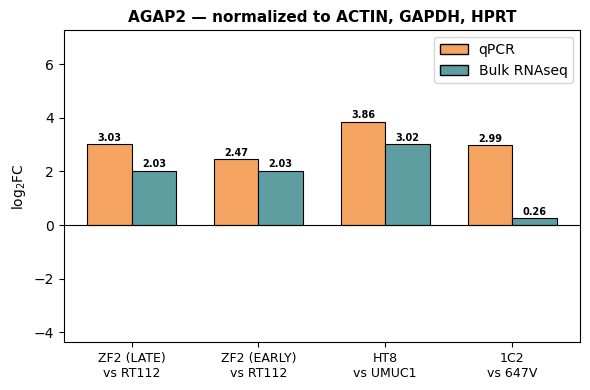

Saved as qpcr_vs_rnaseq_AGAP2.png


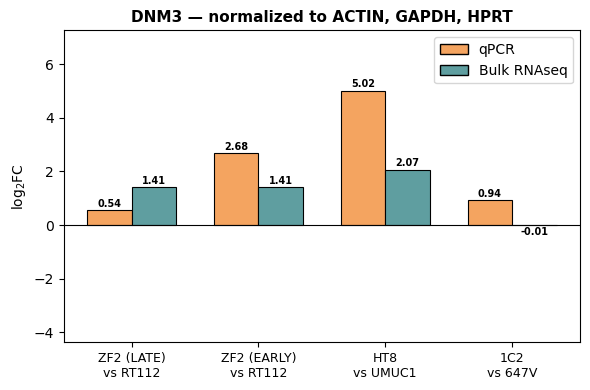

Saved as qpcr_vs_rnaseq_DNM3.png


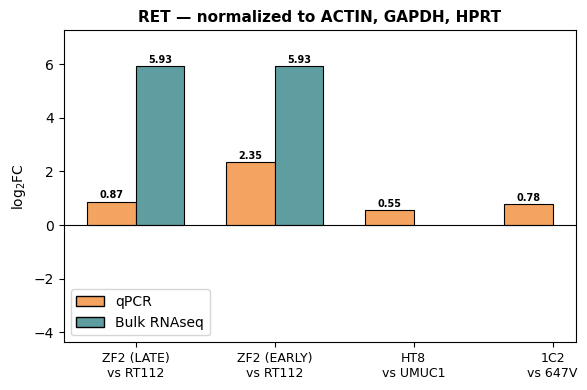

Saved as qpcr_vs_rnaseq_RET.png


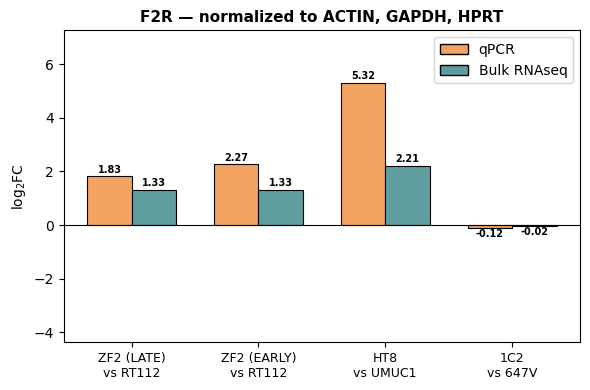

Saved as qpcr_vs_rnaseq_F2R.png


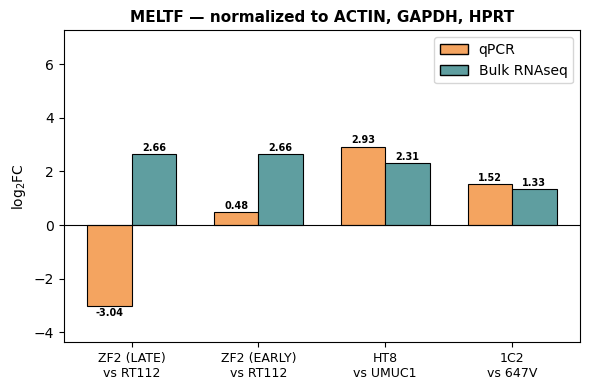

Saved as qpcr_vs_rnaseq_MELTF.png


In [55]:
individual_plot_qpcr_vs_rnaseq(
    qpcr_df=pd.concat([umuc1_ht8_qpcr_df, rt112_2f2e_2f2l_qpcr_df, v647_1c2_qpcr_df]),
    rnaseq_dfs=[
    rt112_2f2e_2f2l_rnaseq_df,   # ZF2 (LATE) vs RT112
    rt112_2f2e_2f2l_rnaseq_df,   # ZF2 (EARLY) vs RT112
    umuc1_ht8_rnaseq_df,          # HT8 vs UMUC1
    v647_1c2_rnaseq_df            # 1C2 vs 647V
],
    comparisons=[
        ("ZF2 (LATE)", "RT112"),
        ("ZF2 (EARLY)", "RT112"),
        ("HT8", "UMUC1"),
        ("1C2", "647V")
    ],
    hkg=["actin", "gapdh", "hprt"],
    color1='sandybrown',
    color2='cadetblue',
    genes_to_include=['AGAP2','DNM3','RET','F2R','MELTF']
)

In [23]:
umuc1_ht8_rnaseq_df

,baseMean,log2FoldChange,lfcSE,pvalue,padj,GeneSymbol,gene_type
0,7498.789751,-2.335216,0.053240,0.000000,0.000000,S100A14,protein_coding
1,4147.558405,-3.142345,0.073502,0.000000,0.000000,PBX1,protein_coding
2,9536.176009,1.998321,0.048639,0.000000,0.000000,EPHX1,protein_coding
3,6757.812006,-3.355842,0.055428,0.000000,0.000000,SCCPDH,protein_coding
4,3632.633727,-3.132228,0.076805,0.000000,0.000000,SEMA3F,protein_coding
...,...,...,...,...,...,...,...
24302,117.519958,0.000746,0.281659,0.999523,0.999691,COX16,protein_coding
24303,339.831941,0.000164,0.153745,0.999666,0.999790,NDUFA11,protein_coding
24304,2.792314,0.000637,0.660734,0.999829,0.999875,RP11-151A6.4,sense_intronic
24305,6.643244,0.001049,0.581025,0.999834,0.999875,RP11-143K11.7,antisense


In [24]:
rt112_2f2e_2f2l_rnaseq_df

,baseMean,log2FoldChange,lfcSE,pvalue,padj,GeneSymbol,gene_type
0,1933.153304,-3.371088,0.083777,0.000000,0.000000,F3,protein_coding
1,7291.676853,5.950702,0.084651,0.000000,0.000000,TXNIP,protein_coding
2,1894.517793,-4.159758,0.099946,0.000000,0.000000,DHRS9,protein_coding
3,1409.878109,-4.871269,0.118664,0.000000,0.000000,AREG,protein_coding
4,1662.933358,-3.881998,0.092718,0.000000,0.000000,SLC7A11,protein_coding
...,...,...,...,...,...,...,...
24516,673.297854,0.000190,0.100564,0.999590,0.999753,NEURL4,protein_coding
24517,2.990742,0.000552,0.604188,0.999775,0.999898,RP4-612C19.2,processed_pseudogene
24518,4.795836,0.000778,0.579535,0.999902,0.999902,RP11-392O17.2,lincRNA
24519,22.054377,0.000676,0.385402,0.999900,0.999902,LINC00216,lincRNA


In [25]:
v647_1c2_rnaseq_df

,baseMean,log2FoldChange,lfcSE,pvalue,padj,GeneSymbol,gene_type
0,4694.531910,-3.794440,0.070754,0.000000e+00,0.000000e+00,H19,processed_transcript
1,20097.820400,1.461745,0.042445,2.930000e-261,1.890000e-257,SERPINE1,protein_coding
2,1570.687691,2.088853,0.076321,7.650000e-166,3.300000e-162,CYP26B1,protein_coding
3,2945.987210,1.176678,0.063299,5.070000e-78,1.640000e-74,ITGA2,protein_coding
4,9070.197090,1.206207,0.067334,2.630000e-72,6.810000e-69,GPRC5A,protein_coding
...,...,...,...,...,...,...,...
21466,0.551443,-0.003688,0.221832,3.845854e-01,NaN,AC009235.4,processed_pseudogene
21467,0.655140,0.004744,0.221592,2.842383e-01,NaN,CD24L4,processed_pseudogene
21468,0.924396,-0.000465,0.221418,4.169714e-01,NaN,RP11-576C2.1,transcribed_processed_pseudogene
21469,4.840799,-0.012903,0.220905,8.912640e-01,NaN,RP11-424G14.1,lincRNA
